In [521]:
# AI was used to assist code development
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [522]:
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
pd.set_option('display.max_columns', None)
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,doneDisconnectTimespan,connectionTimespan,doneChargingTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 01:39:40,0 days 06:02:21,0 days 04:22:41,1,Thursday,2020,False,5,11,9.0,262.683333,362.350000,0.724944
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 02:20:16,0 days 09:01:31,0 days 06:41:15,1,Thursday,2020,False,5,14,12.0,401.250000,541.516667,0.740974
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 08:04:16,0 days 10:42:47,0 days 02:38:31,1,Thursday,2020,False,5,16,8.0,158.516667,642.783333,0.246610
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00,0 days 01:19:54,0 days 02:38:41,0 days 01:18:47,1,Thursday,2020,False,5,8,7.0,78.783333,158.683333,0.496481
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 03:51:10,0 days 08:08:39,0 days 04:17:29,1,Thursday,2020,False,6,14,10.0,257.483333,488.650000,0.526928


<h3>Selection of features</h3> 
<p>Since the task is to find clusters for archetypical charging sessions and not for how requests from registered users deviate from the actual charging session, we decided to only incorporate features that are not in the user inputs. Moreover, we calculated two measures from connectionTime, disconnectTime and doneChargingTime. The charging_duration is the timespan between connectionTime and doneChargingTime and the idle_time is the timespan from doneChargingTime to disconnectTime. With this calculation we decreased dimensionality from 4 to only 3 explainable features.</p>

In [523]:
# Calculate timespans
full_charging_df['session_duration'] = (full_charging_df['disconnectTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['charging_duration'] = (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['idle_time'] = (full_charging_df['disconnectTime'] - full_charging_df['doneChargingTime']).dt.total_seconds() / 60

# Calculate the deviation between the requested departure time and the actual disconnection time
full_charging_df['session_deviation'] = (full_charging_df['requestedDeparture'] - full_charging_df['disconnectTime']).dt.total_seconds() / 60

In [524]:
# Select features for clustering
relevantFeatures = [
    'session_duration',
    'charging_duration',
    'idle_time',
    'session_deviation',
    'kWhRequested',
    'kWhDelivered',
    'minutesAvailable',
]

In [525]:
X = full_charging_df[relevantFeatures].dropna()

# Compare sizes before and after dropping NaNs
print(full_charging_df[relevantFeatures].shape)
print(X.shape)

(65037, 7)
(44638, 7)


In [526]:
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,session_duration,charging_duration,idle_time,session_deviation,kWhRequested,kWhDelivered,minutesAvailable
0,-0.149908,0.242613,-0.374487,0.556382,0.002317,1.086272,0.549934
1,0.543841,1.040264,-0.186459,0.377972,2.177351,1.834937,1.219736
2,0.935955,-0.357016,1.406681,-2.028731,-0.819363,-0.627198,-1.494993
3,-0.938523,-0.815996,-0.466031,-0.178692,-0.819363,-1.013158,-1.469621
4,0.339137,0.212680,0.234519,0.233731,-0.432690,0.007791,0.757978


In [527]:
k_max = 50
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

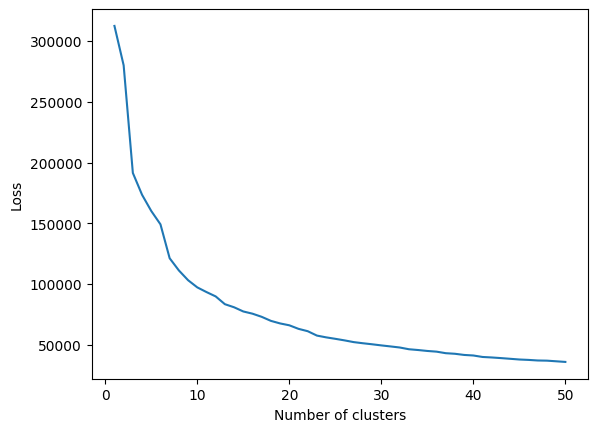

In [528]:
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.show()

(0.0, 20.0)

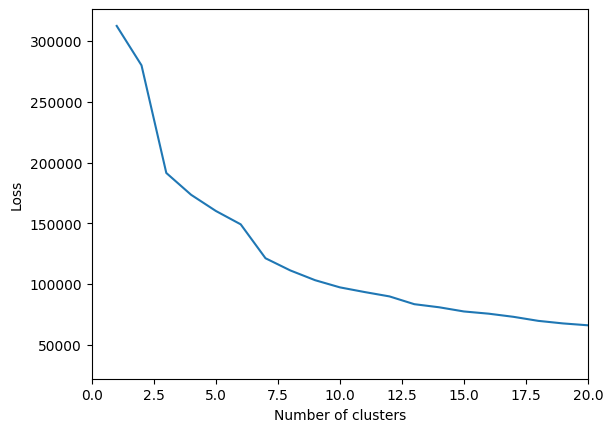

In [529]:
# Zoom in
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim([0,20])

In [530]:
# refit algorithm
seven_means = KMeans(n_clusters=7, n_init='auto', random_state=42)
seven_means.fit(clustering_scaled_df)

# match records to clusters by calling predict
seven_means.predict(clustering_scaled_df)

array([5, 3, 4, ..., 1, 1, 1], dtype=int32)

In [531]:
numbers = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5", "Cluster 6", "Cluster 7"]


# TEMP: Commented out for speed

# clustering_scaled_df["7 Clusters"] = seven_means.predict(clustering_scaled)
# clustering_scaled_df["7 Clusters"] = clustering_scaled_df["7 Clusters"].apply(lambda x: numbers[x])
# sns.pairplot(data=clustering_scaled_df, hue="7 Clusters")

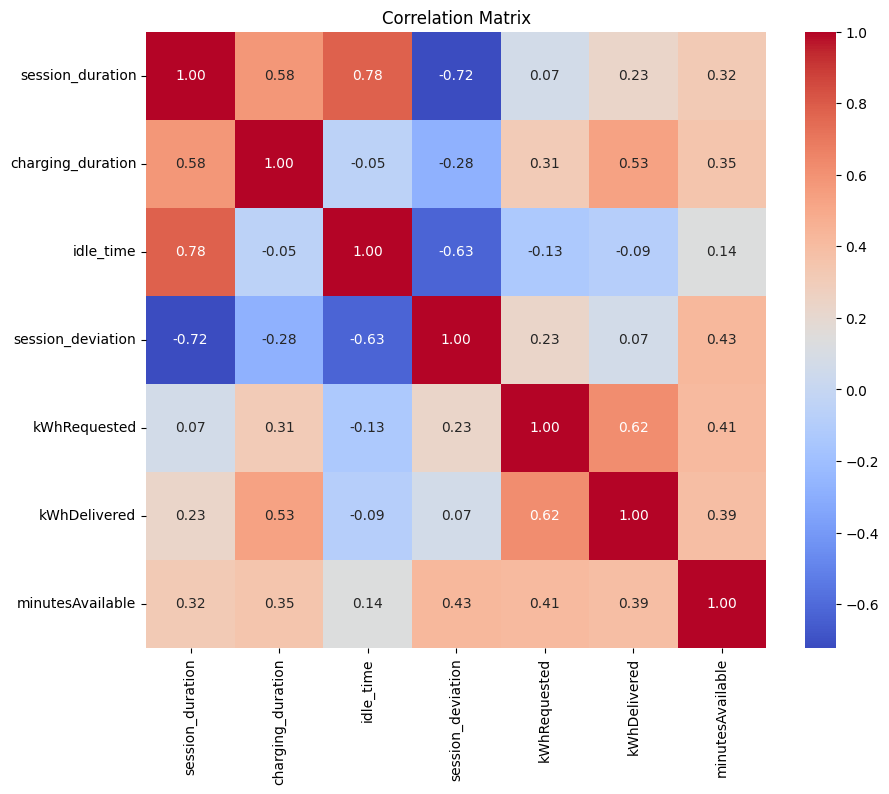

In [532]:
# Correlation Matrix Heatmap
correlation_matrix = full_charging_df[relevantFeatures].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

NOTES:
- Correlation between charging duration and kWhDelivered: 0.5319936654405534

In [533]:
# Select features for clustering
features = [
    'session_duration',
    'kWhDelivered'
]

In [534]:
# Drop rows with NaN values
X = full_charging_df[features].dropna()

# Compare sizes before and after dropping NaNs
print(full_charging_df[features].shape)
print(X.shape)

X.head()

(65037, 2)
(65037, 2)


,session_duration,kWhDelivered
0,362.350000,25.016
1,541.516667,33.097
2,642.783333,6.521
3,158.683333,2.355
4,488.650000,13.375


In [535]:
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,session_duration,kWhDelivered
0,-0.048296,1.292140
1,0.562441,2.078317
2,0.907635,-0.507186
3,-0.742547,-0.912484
4,0.382231,0.159620


In [536]:
k_max = 15
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

(0.0, 14.0)

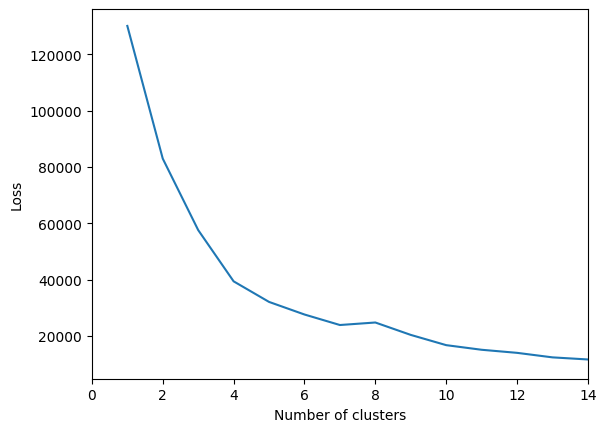

In [537]:
# Plot the loss curve to find the optimal number of clusters
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim([0,14])

In [538]:
numbers = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5"]


/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


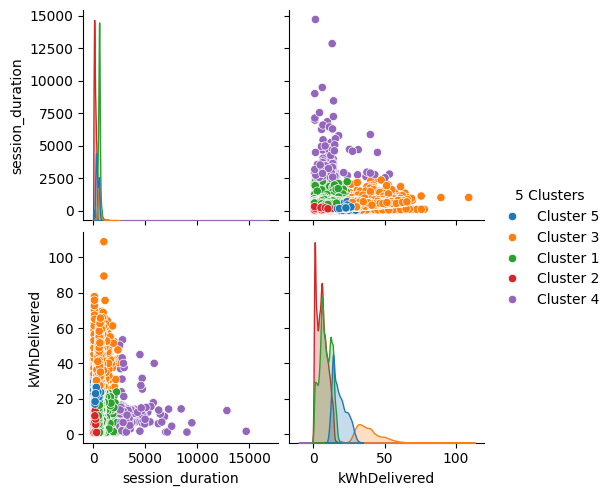

In [539]:
# Test with 5 clusters first

five_means = KMeans(n_clusters=5, n_init='auto', random_state=42)
# Fit algorithm for 5 clusters
five_means.fit(clustering_scaled_df)
X["5 Clusters"] = five_means.predict(clustering_scaled)
X["5 Clusters"] = X["5 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="5 Clusters")

/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


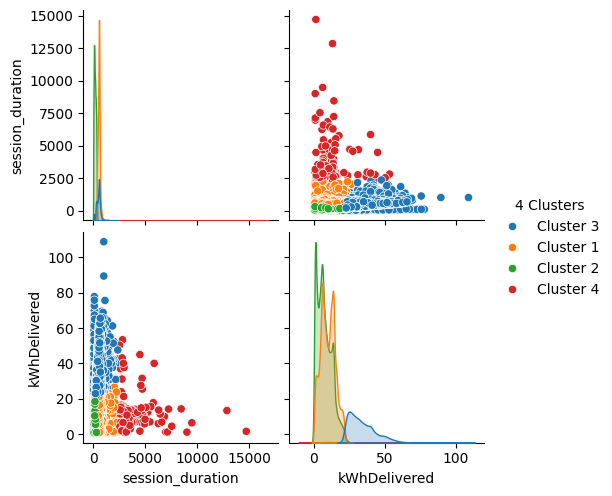

In [540]:
four_means = KMeans(n_clusters=4, n_init='auto', random_state=42)
# Fit algorithm for 4 clusters
four_means.fit(clustering_scaled_df)
X["4 Clusters"] = four_means.predict(clustering_scaled)
X["4 Clusters"] = X["4 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="4 Clusters")

4 Clusters
Cluster 2    29619
Cluster 1    27030
Cluster 3     8260
Cluster 4      128
Name: count, dtype: int64


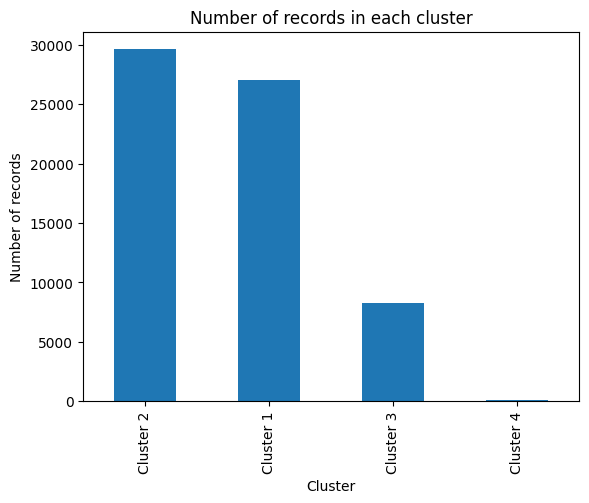

In [554]:
# Length of each cluster
print(X["4 Clusters"].value_counts())

# Bar Chart plot
X["4 Clusters"].value_counts().plot(kind='bar')
plt.title("Number of records in each cluster")
plt.ylabel("Number of records")
plt.xlabel("Cluster")
plt.show()

In [559]:
X.groupby("4 Clusters")[features].describe()

session_duration                                         \
                      count         mean          std          min   
4 Clusters                                                           
Cluster 1           27030.0   553.914760   142.775175   297.000000   
Cluster 2           29619.0   168.313057    95.172922     2.066667   
Cluster 3            8260.0   485.412536   202.672329     2.550000   
Cluster 4             128.0  4066.555339  1909.804431  2331.633333   

                                                                kWhDelivered  \
                    25%          50%          75%           max        count   
4 Clusters                                                                     
Cluster 1    480.391667   548.608333   600.091667   2308.050000      27030.0   
Cluster 2     88.533333   159.383333   243.800000    402.216667      29619.0   
Cluster 3    351.316667   513.066667   583.583333   2368.700000       8260.0   
Cluster 4   2781.862500  3581.041667  4713.408333  14716.150000        128.0   

                                                                      \
                 mean        std     min      25%      50%       75%   
4 Clusters                                                             
Cluster 1    9.821190   5.034204   0.506   5.8960   9.6305  13.59000   
Cluster 2    7.319840   5.053676   0.501   3.1545   6.3610  10.89200   
Cluster 3   33.813252   9.295845  21.145  26.3075  31.7545  39.68250   
Cluster 4   12.440047  10.337653   0.896   6.4655  11.2745  13.99725   

                        
                   max  
4 Clusters              
Cluster 1    26.513000  
Cluster 2    24.830000  
Cluster 3   108.797242  
Cluster 4    53.282000

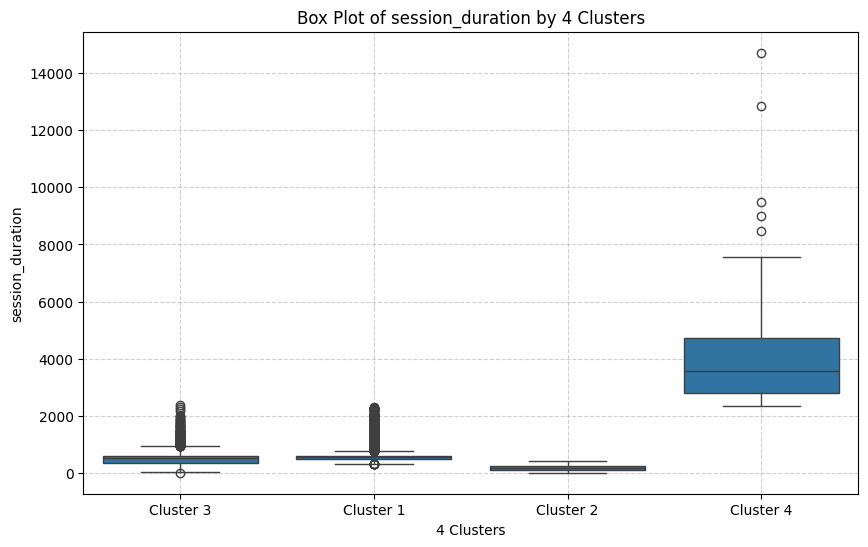

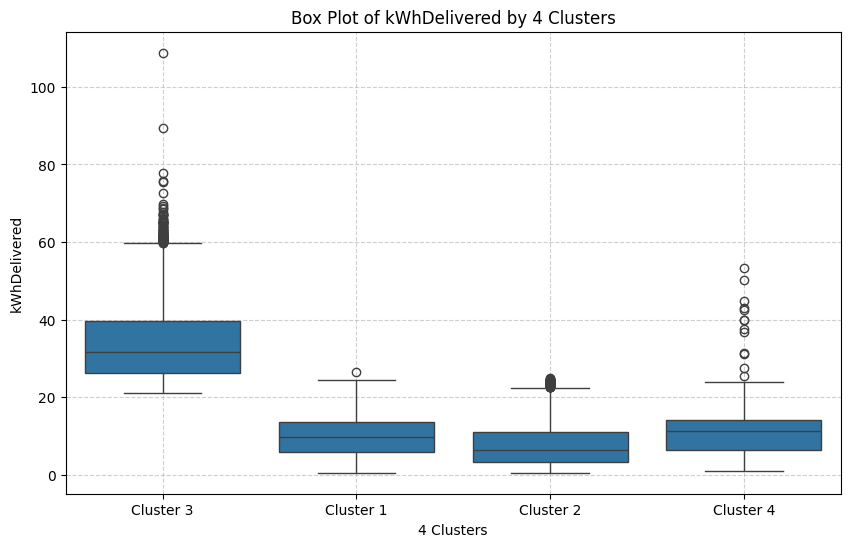

In [562]:
# Box Whisker plot
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=X, x='4 Clusters', y=feature)
    plt.title(f'Box Plot of {feature} by 4 Clusters')
    plt.xlabel('4 Clusters')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [ ]:
# 
# print(X[features].agg(['min', 'max', 'median']))

In [563]:
# Distribution (Min, max, median and other values) of the kWhDelivered and session_duration for the whole dataset
X[features].describe()

,session_duration,kWhDelivered
count,65037.000000,65037.000000
mean,376.518090,11.734288
std,293.363741,10.278928
min,2.066667,0.501000
25%,169.983333,5.060000
50%,369.450000,9.099000
75%,552.366667,14.127000
max,14716.150000,108.797242


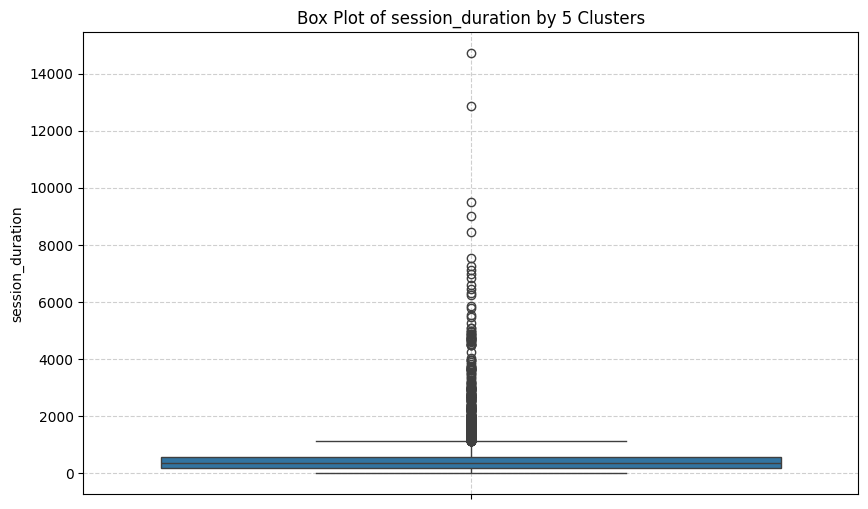

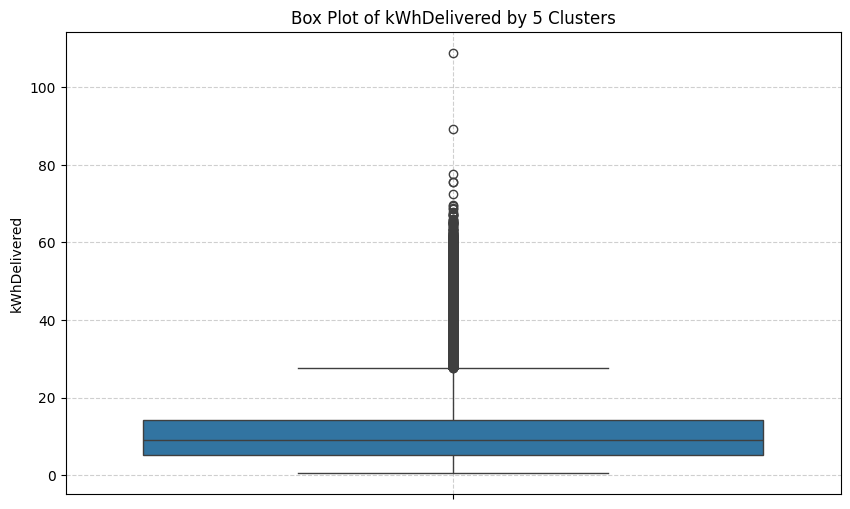

In [565]:
# Box Whisker plot
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=X, y=feature)
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

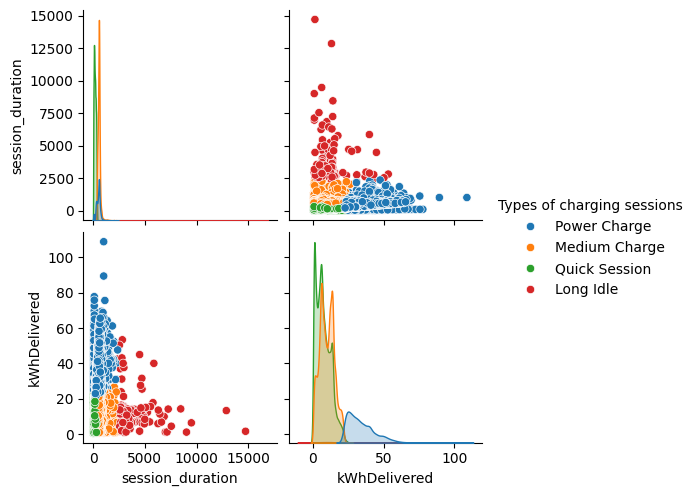

In [544]:
# Rename labels in plot

# New labels
new_mappings = {
    "Cluster 1": "Medium Charge",
    "Cluster 2": "Quick Session",
    "Cluster 3": "Power Charge",
    "Cluster 4": "Long Idle"
}

# Replace cluster names based on the mapping
X["Types of charging sessions"] = X["4 Clusters"].replace(new_mappings)

# Plot with the new labels
sns.pairplot(data=X, hue="Types of charging sessions")


<h4>Cluster Description</h4>
<p><b>Cluster 1: Medium Charge </b>-> Charging Events with a medium high session_duration and an average kWh_delivered</p>
<p><b>Cluster 2: Quick Session </b>-> Short charging time with relatively low energy consumption </p>
<p><b>Cluster 3: Power Charge </b>-> Use the highest amount of energy, but are connected within a regular session duration</p>
<p><b>Cluster 4: Long Idle </b>-> Stays connected for a long time, but doesn't charge the whole time</p>

In [545]:
# User_df is the same as full charging df but the columns are dropped where the features are nan
user_df = full_charging_df.dropna(subset=features)
print(X.shape)
print(user_df.shape)

(65037, 5)
(65037, 36)


In [546]:
# Append 4 Clusters column on user_df
user_df["Types of charging sessions"] = X["Types of charging sessions"]
# Drop rows with userID that occours in general less than 10 times
user_df = user_df[user_df.groupby('userID')['userID'].transform('size') >= 10]
# Add a column with the number of sessions per user
user_df["Number of sessions per userID"] = user_df.groupby('userID')['userID'].transform('size')

# Assuming user_df is your DataFrame and it has a column named 'userID'
grouped_user_df = user_df.groupby('userID').size()

# Print the length of each group
grouped_user_df

userID
22.0       58
61.0       43
66.0       44
67.0       61
68.0       69
           ..
16140.0    12
16581.0    15
16635.0    10
17097.0    11
17953.0    38
Length: 569, dtype: int64

In [547]:
# Check cluster consistency for each userId
user_cluster_stats = (
    user_df.groupby('userID')['Types of charging sessions']
    .value_counts(normalize=True)  # Get proportion of sessions in each cluster
    .reset_index(name='proportion')
)

user_cluster_stats

,userID,Types of charging sessions,proportion
0,22.0,Medium Charge,0.362069
1,22.0,Quick Session,0.362069
2,22.0,Power Charge,0.275862
3,61.0,Medium Charge,0.837209
4,61.0,Power Charge,0.116279
...,...,...,...
1317,16635.0,Quick Session,0.500000
1318,17097.0,Quick Session,0.818182
1319,17097.0,Power Charge,0.181818
1320,17953.0,Quick Session,0.842105


In [548]:
# Find the dominant cluster for each user
dominant_clusters = user_cluster_stats.loc[user_cluster_stats.groupby('userID')['proportion'].idxmax()].reset_index(drop=True)

# Only keep users where the dominant cluster is more than 80% of their sessions
dominant_clusters = dominant_clusters[dominant_clusters['proportion'] > 0.8]

# Percentage of users with a dominant cluster
percentage_dominant = dominant_clusters.shape[0] / user_df['userID'].nunique() * 100
print(f"Percentage of users with a dominant cluster: {percentage_dominant:.2f}%")

# Rename the columns for clarity
dominant_clusters = dominant_clusters.rename(columns={'Types of charging sessions': 'dominant_cluster', 'proportion': 'consistency_score'})

dominant_clusters

Percentage of users with a dominant cluster: 38.66%


,userID,dominant_cluster,consistency_score
1,61.0,Medium Charge,0.837209
3,67.0,Power Charge,0.803279
6,76.0,Quick Session,0.965347
7,159.0,Medium Charge,0.914286
9,169.0,Medium Charge,0.827977
...,...,...,...
561,15724.0,Power Charge,0.863636
562,15756.0,Quick Session,1.000000
564,16140.0,Medium Charge,1.000000
567,17097.0,Quick Session,0.818182


In [549]:
# Calculate the total number of users
total_users = dominant_clusters['dominant_cluster'].value_counts().sum()
print(total_users)

# Add a percentage column
cluster_counts = dominant_clusters['dominant_cluster'].value_counts().reset_index()
cluster_counts.columns = ['dominant_cluster', 'count']
cluster_counts['percentage'] = (cluster_counts['count'] / total_users) * 100
print(cluster_counts)

220
  dominant_cluster  count  percentage
0    Quick Session    100   45.454545
1    Medium Charge     90   40.909091
2     Power Charge     30   13.636364


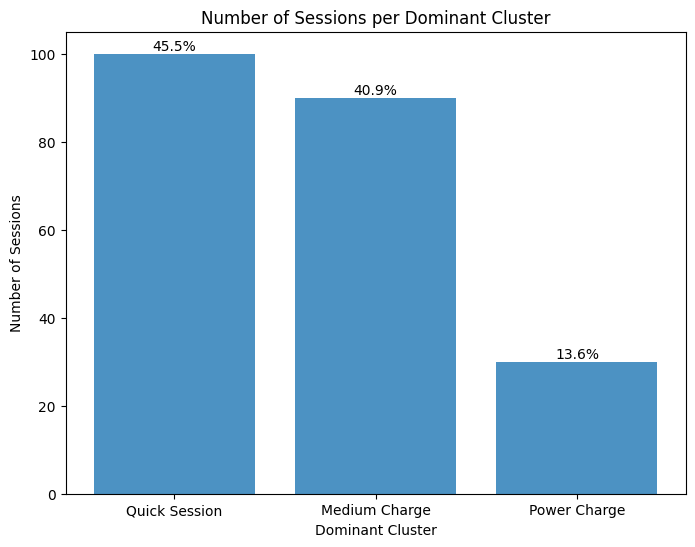

In [550]:
# Plot the counts
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts['dominant_cluster'], cluster_counts['count'], alpha=0.8, label='Count')

# Add percentages on top of the bars
for i, row in cluster_counts.iterrows():
    plt.text(row['dominant_cluster'], row['count'], f"{row['percentage']:.1f}%", ha='center', va='bottom')

# Add labels and title
plt.xlabel('Dominant Cluster')
plt.ylabel('Number of Sessions')
plt.title('Number of Sessions per Dominant Cluster')
plt.show()

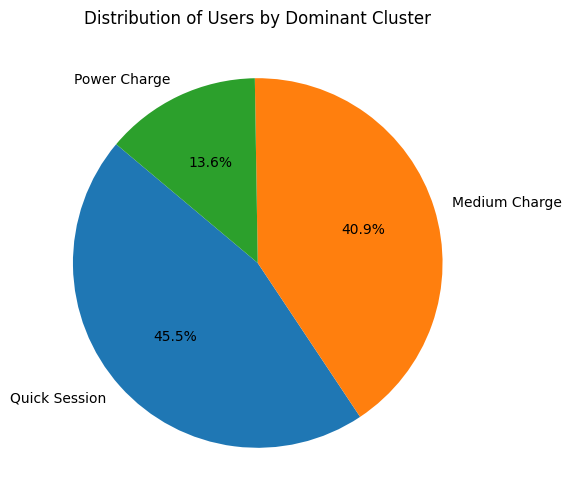

In [551]:
# Pie chart
plt.figure(figsize=(8, 6))
plt.pie(cluster_counts['percentage'], labels=cluster_counts['dominant_cluster'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Users by Dominant Cluster')
plt.show()

In [552]:
# Add back the number of sessions per userID
dominant_clusters = dominant_clusters.merge(
    user_df['Number of sessions per userID'],
    left_on='userID',
    right_index=True
)

dominant_clusters

,userID,dominant_cluster,consistency_score,Number of sessions per userID
1,61.0,Medium Charge,0.837209,491
3,67.0,Power Charge,0.803279,201
6,76.0,Quick Session,0.965347,192
7,159.0,Medium Charge,0.914286,168
9,169.0,Medium Charge,0.827977,93
...,...,...,...,...
561,15724.0,Power Charge,0.863636,491
562,15756.0,Quick Session,1.000000,148
564,16140.0,Medium Charge,1.000000,344
567,17097.0,Quick Session,0.818182,46
